# Import libraries and Dataset overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/home/zhgx/Portfolio_Adrian_Paneda/ecommerce-analytics-project/data_sample/clean_data.csv")

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-02 02:49:24+00:00,view,1500208,2053013552955916539,computers.peripherals.printer,xerox,94.98,517567639,69e6455e-60ba-45aa-8adf-e2f8368b38e2
1,2019-10-03 09:22:26+00:00,view,26402505,2053013563651392361,unknown,unknown,950.73,515486711,530fd038-f953-4642-ae76-899927504bcc
2,2019-10-02 18:06:36+00:00,view,3801361,2053013566176363511,appliances.iron,tefal,84.69,512990124,7383f94e-d0a2-48d8-9ced-f73c4b16db45
3,2019-10-03 16:12:48+00:00,view,11600016,2053013554566529381,computers.desktop,microlab,179.12,518802500,f18c0549-4e6b-4058-a75f-50ef19ea9340
4,2019-10-01 06:38:24+00:00,view,17400231,2053013558727279193,unknown,unknown,3.09,519078297,aeceaca3-8b2b-4540-9a34-98cc9ff37f4e


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99869 entries, 0 to 99868
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     99869 non-null  object 
 1   event_type     99869 non-null  object 
 2   product_id     99869 non-null  int64  
 3   category_id    99869 non-null  int64  
 4   category_code  99869 non-null  object 
 5   brand          99869 non-null  object 
 6   price          99869 non-null  float64
 7   user_id        99869 non-null  int64  
 8   user_session   99869 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB


In [3]:
df.describe()

,product_id,category_id,price,user_id
count,9.986900e+04,9.986900e+04,99869.000000,9.986900e+04
mean,1.030665e+07,2.056577e+18,298.741872,5.315125e+08
std,1.136843e+07,1.639457e+16,368.921575,1.695653e+07
min,1.001588e+06,2.053014e+18,0.790000,2.920719e+08
25%,1.005115e+06,2.053014e+18,65.610000,5.156266e+08
50%,5.000475e+06,2.053014e+18,164.160000,5.274887e+08
75%,1.640017e+07,2.053014e+18,368.040000,5.484138e+08
max,5.390001e+07,2.175420e+18,2574.070000,5.565461e+08


In [4]:
df.shape

(99869, 9)

### Correlation Matrix of Daily Metrics

In [21]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.columns

Index(['product_id', 'category_id', 'price', 'user_id'], dtype='object')

In [22]:
daily_stats = pd.DataFrame({
    "events": df.groupby("day").size(),
    "users": df.groupby("day")["user_id"].nunique(),
    "purchases": df[df["event_type"] == "purchase"].groupby("day").size(),
    "revenue": df[df["event_type"] == "purchase"].groupby("day")["price"].sum()
})

daily_stats = daily_stats.fillna(0)

daily_stats

,events,users,purchases,revenue
day,,,,
2019-10-01,35043,27673,520,169317.90
2019-10-02,33525,26661,556,190899.29
2019-10-03,31301,24784,534,179038.70


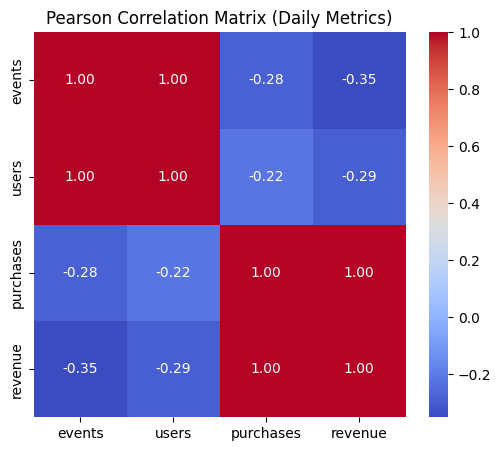

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = daily_stats.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearson Correlation Matrix (Daily Metrics)")
plt.show()

**Interpretation**

This correlation matrix shows the relationship between daily activity and business metrics.

- As expected, *purchases* and *revenue* are almost perfectly correlated, since revenue is directly driven by the number of purchases.
- *Events* and *users* are also highly correlated, which indicates that daily activity scales mainly with the number of active users.
- Interestingly, activity metrics (events, users) show a moderate negative correlation with purchases and revenue.  
  This suggests that higher traffic days are not necessarily the most profitable days, and conversion efficiency may vary across time.

Overall, this matrix highlights the difference between *volume of activity* and *quality of activity*.

Event type distribution

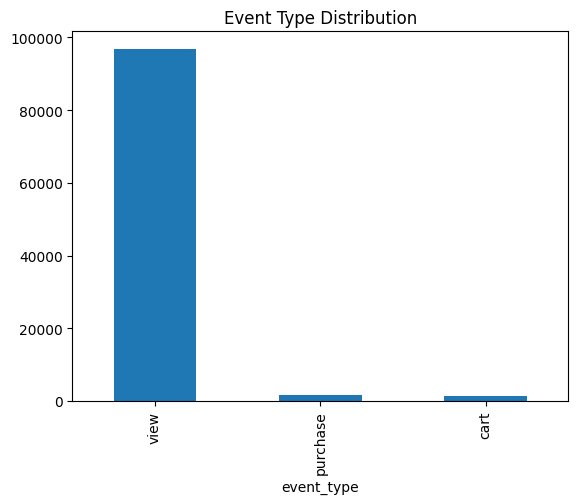

In [5]:
event_counts = df["event_type"].value_counts()

event_counts.plot(kind="bar", title="Event Type Distribution")
plt.show()

**Interpretation**

This bar chart shows the distribution of user actions across the main event types.

- As expected, *view* events largely dominate the dataset, since every user interaction starts with a product view.
- *Cart* and *purchase* events represent a much smaller fraction of the total activity, which reflects the typical structure of an e-commerce funnel.

This strong imbalance highlights the importance of analyzing conversion rates between stages (view → cart → purchase), as small changes in these transitions can have a large impact on revenue.

In [6]:
df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

df["event_time"].dtype

datetime64[ns, UTC]

### Daily Number of Events

We aggregate the raw event-level data by day in order to analyze the overall volume of platform activity over time.

This metric reflects the total number of user interactions per day and provides a first view of traffic dynamics.

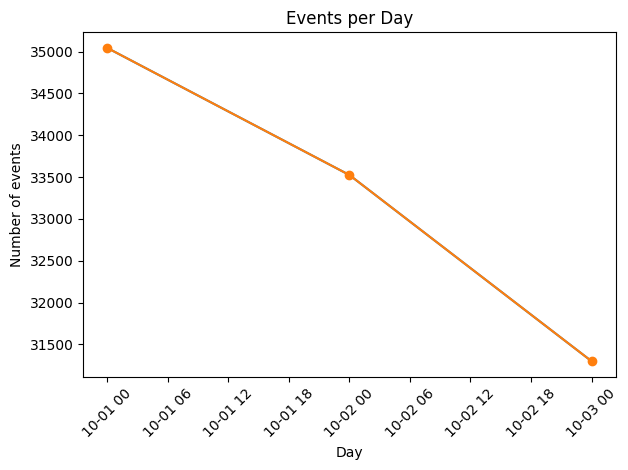

In [26]:
df["day"] = df["event_time"].dt.date

events_per_day = df.groupby("day").size()

events_per_day.plot(title="Events per Day")
events_per_day.plot(title="Events per Day", marker="o")
plt.xlabel("Day")
plt.ylabel("Number of events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation**

The number of events shows a decreasing trend over the observed period.

However, this pattern should be interpreted with caution, since the dataset only covers a very short time window (three days).  
This metric will be analyzed together with active users, purchases, and revenue to assess whether this decrease reflects lower traffic, lower engagement, or changes in conversion behavior.

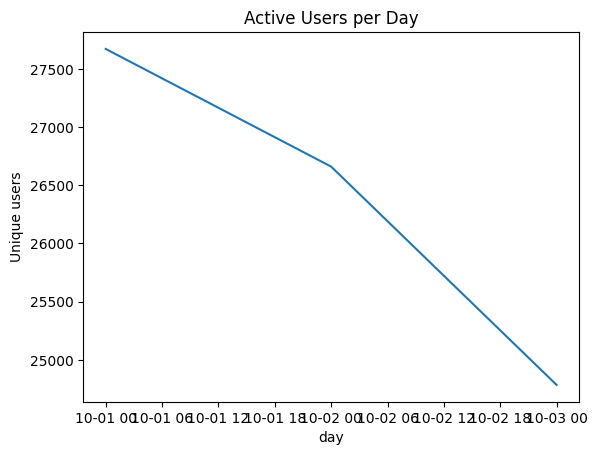

In [8]:
users_per_day = df.groupby("day")["user_id"].nunique()

users_per_day.plot(title="Active Users per Day")
plt.ylabel("Unique users")
plt.show()

**Interpretation**

This bar chart shows the distribution of user actions across the main event types.

- As expected, *view* events largely dominate the dataset, since every user interaction starts with a product view.
- *Cart* and *purchase* events represent a much smaller fraction of the total activity, which reflects the typical structure of an e-commerce funnel.

This strong imbalance highlights the importance of analyzing conversion rates between stages (view → cart → purchase), as small changes in these transitions can have a large impact on revenue.

### User and Session-Level Engagement

In [9]:
events_per_user = df.groupby("user_id").size()

events_per_user.describe()

count    74981.000000
mean         1.331924
std          0.827371
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         24.000000
dtype: float64

**Interpretation – Events per User**

The distribution of events per user is highly right-skewed.

- The median and 75th percentile are equal to 1, which indicates that most users interact with the platform only once.
- A small fraction of users generates a disproportionately large number of events, as shown by the long right tail (maximum of 24 events).

This suggests a strong heterogeneity in user engagement, with a small group of highly active users and a large majority of low-engagement users.

In [10]:
events_per_session = df.groupby("user_session").size()

events_per_session.describe()

count    85400.000000
mean         1.169426
std          0.495197
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         12.000000
dtype: float64

**Interpretation – Events per Session**

The number of events per session is even more concentrated.

- The median, 75th percentile, and even the 90th percentile are equal to 1, which indicates that most sessions consist of a single interaction.
- Only a very small fraction of sessions include multiple actions, with a maximum of 12 events in a single session.

This suggests that most user sessions are very short, which may reflect quick bounces or highly goal-oriented interactions.

### Conversion Funnel (Unique Users)

We analyze the number of unique users at each stage of the funnel: view → cart → purchase.

In [11]:
funnel = (
    df.groupby("event_type")["user_id"]
      .nunique()
      .reindex(["view", "cart", "purchase"])
)

funnel

event_type
view        73022
cart         1396
purchase     1569
Name: user_id, dtype: int64

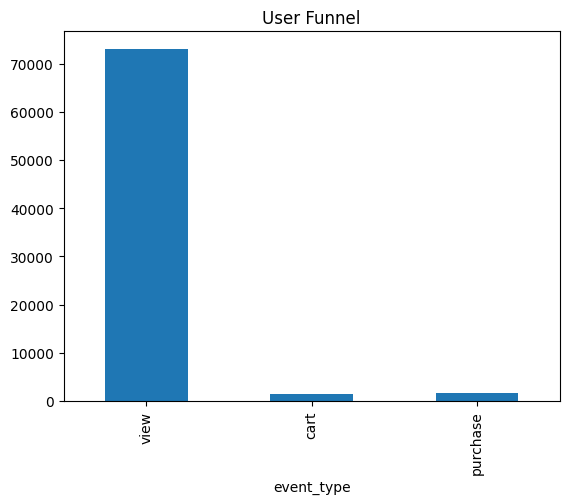

In [27]:
funnel.plot(kind="bar", title="User Funnel")
plt.show()

**Interpretation**

- A very large number of users view products, but only a small fraction reaches the cart stage.
- Interestingly, the number of users who make a purchase is slightly higher than the number of users who appear in the cart stage.

This suggests that some purchases may occur without an explicit cart event (e.g., direct purchase flows or missing tracking events).

Overall, this funnel reveals a very strong drop-off between product views and purchases, highlighting conversion as a key lever for business improvement.

### Funnel Conversion Rates

We compute the main conversion rates between stages of the funnel.

In [12]:
view_to_cart = funnel["cart"] / funnel["view"]
cart_to_purchase = funnel["purchase"] / funnel["cart"]
view_to_purchase = funnel["purchase"] / funnel["view"]

view_to_cart, cart_to_purchase, view_to_purchase

(np.float64(0.019117526224973296),
 np.float64(1.1239255014326648),
 np.float64(0.02148667524855523))

**Interpretation**

- The view → cart conversion rate is very low (around 2%), which indicates a strong drop-off immediately after product views.
- Interestingly, the cart → purchase conversion rate is greater than 100%.

This unexpected result suggests that a significant number of purchases occur without a recorded cart event, possibly due to:
- direct purchase flows (e.g., "buy now" actions), or  
- missing or incomplete tracking of cart events.

Overall, the view → purchase conversion rate is approximately 2%, which highlights conversion optimization as a major opportunity for improving business performance.

### Distribution of Purchase Prices

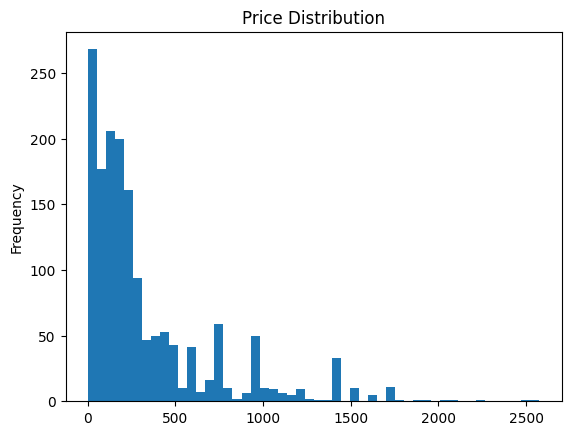

In [14]:
purchases = df[df["event_type"] == "purchase"]

purchases["price"].describe()

purchases["price"].plot(kind="hist", bins=50, title="Price Distribution")
plt.show()

**Interpretation**

The distribution of purchase prices is highly right-skewed.

- Most purchases are concentrated at relatively low price levels.
- There is a long right tail with a small number of very high-priced items, reaching values above 2,000.

This indicates that revenue is likely driven by a combination of:
- a large volume of low-priced purchases, and  
- a small number of high-priced transactions that can have a disproportionate impact on total revenue.

Such a distribution suggests that both pricing strategy and product mix play a key role in overall business performance.

### Daily Revenue Analysis

In [15]:
df["day"] = df["event_time"].dt.date

df[["event_time", "day"]].head()

,event_time,day
0,2019-10-02 02:49:24+00:00,2019-10-02
1,2019-10-03 09:22:26+00:00,2019-10-03
2,2019-10-02 18:06:36+00:00,2019-10-02
3,2019-10-03 16:12:48+00:00,2019-10-03
4,2019-10-01 06:38:24+00:00,2019-10-01


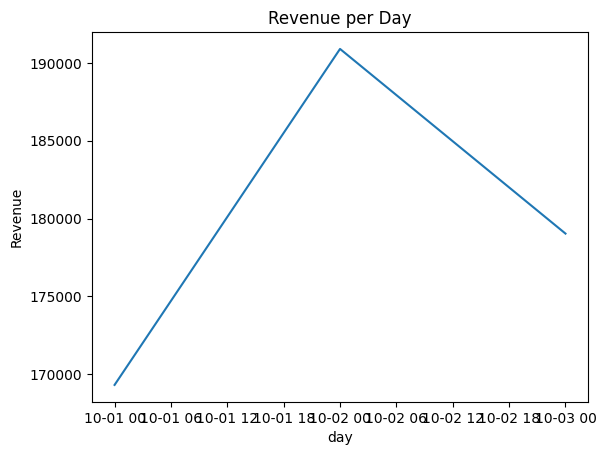

In [16]:
revenue_per_day = (
    purchases.groupby("day")["price"]
             .sum()
)

revenue_per_day.plot(title="Revenue per Day")
plt.ylabel("Revenue")
plt.show()

**Interpretation**

Daily revenue shows noticeable variability across the three observed days.

- Revenue peaks on the second day, despite a continuous decrease in both total events and active users.
- This suggests that revenue dynamics are not driven solely by traffic volume, but also by changes in conversion behavior and purchase value.

This result highlights the importance of analyzing traffic and revenue jointly, as higher traffic does not necessarily translate into higher revenue.

### Purchase Behavior at User Level

In [17]:
first_purchase = (
    purchases.groupby("user_id")["event_time"]
             .min()
             .reset_index(name="first_purchase_time")
)

first_purchase.head()

,user_id,first_purchase_time
0,469848615,2019-10-01 16:11:48+00:00
1,511231471,2019-10-01 13:03:40+00:00
2,512364715,2019-10-02 16:10:42+00:00
3,512364731,2019-10-03 12:56:38+00:00
4,512371297,2019-10-02 12:01:22+00:00


**Interpretation – First Purchase Timing**

This table captures the timestamp of the first purchase for each user.

This information is useful to analyze:
- how quickly users convert after their first interaction, and  
- the temporal distribution of first-time buyers.

Such data can be used in future analyses for cohort studies or to estimate time-to-conversion metrics.

In [18]:
purchases_per_user = purchases.groupby("user_id").size()

purchases_per_user.describe()

count    1569.000000
mean        1.026131
std         0.171147
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
dtype: float64

**Interpretation – Purchases per User**

The number of purchases per user is extremely concentrated.

- The median and 75th percentile are equal to 1, which indicates that most users make only a single purchase.
- Only a very small fraction of users make repeat purchases, with a maximum of 3 purchases per user.

This suggests that customer retention is very low in this dataset and that the business model appears to rely mainly on one-time buyers rather than on repeat customers.

## Key Insights / Conclusions

- **Dataset & activity:**  
  The dataset contains a large number of events from thousands of users over several days.  
  Activity is not perfectly stable day-to-day, showing moderate variability in user engagement.

- **Event mix:**  
  The most frequent event type is *view*, while *purchase* events represent a much smaller share of total activity, which is expected in a typical e-commerce funnel.

- **Engagement (user / session level):**  
  The median number of events per user is low, and the distribution shows a clear long-tail pattern, with a small group of heavy users generating a disproportionate number of events.  
  Median events per session indicate relatively short sessions on average.

- **Funnel size (unique users):**  
  A large number of users reach the *view* stage, a much smaller subset reaches *cart*, and only a small fraction completes a *purchase*.  
  The biggest drop-off occurs between the **view and cart** stages, which represents the main funnel bottleneck.

- **Conversion rates:**  
  The overall view-to-purchase conversion rate is low, indicating that many users browse products but only a small percentage complete a transaction.  
  This suggests that the primary opportunity for business impact lies in improving conversion efficiency rather than increasing traffic volume.

- **Pricing:**  
  Purchase prices show a right-skewed distribution with a long tail of high-value transactions.  
  Typical purchase prices are relatively moderate, while a small number of high-priced purchases disproportionately influence total revenue.

- **Revenue pattern:**  
  Daily revenue shows moderate variability and appears to be driven by a combination of consistent transaction volume and sporadic high-value purchases, which aligns with the observed price distribution.

- **Purchase behavior (user level):**  
  Most users make only one purchase, while repeat purchases are relatively rare.  
  Only a very small fraction of users make repeat purchases, with a maximum of three purchases per user.  
  This suggests that customer retention is low in this dataset and that the business model appears to rely mainly on one-time buyers rather than on repeat customers.

**Overall conclusion:**  
The analysis reveals a classic high-volume, low-conversion e-commerce funnel with low repeat purchase rates.  
The main business opportunities lie in improving funnel conversion (especially from view to cart) and developing retention strategies to increase repeat purchases and long-term customer value.